# Common Task 1: Convolutional Autoencoder for Jet Event Reconstruction
## ML4SCI GENIE GSoC Evaluation

This notebook trains a convolutional autoencoder to reconstruct jet events from the Quark/Gluon dataset.  
Each event contains 3 detector channels (ECAL, HCAL, Tracks) as 125×125 images.

**Key improvements over baseline:**
- Upsample + Conv2d decoder (no checkerboard artifacts from ConvTranspose2d)
- Combined loss: MSE + SSIM + false-activation penalty for sparse reconstruction
- Gradient clipping & ReduceLROnPlateau for training stability


In [4]:
!pip install pytorch-msssim


In [5]:
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as compare_ssim
from pytorch_msssim import ssim as compute_ssim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [10]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/quark-gluon_data-set_n139306 (1).hdf5'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = "C:/Users/anjal/Downloads/Genie-Task/data/quark-gluon_data-set_n139306 (1).hdf5"

In [11]:
N_SAMPLES = 10000

with h5py.File(DATA_PATH, 'r') as f:
    X = f['X_jets'][:N_SAMPLES]   # (N, 125, 125, 3)
    y = f['y'][:N_SAMPLES]

print(f"Loaded X: {X.shape}, dtype={X.dtype}")
print(f"Loaded y: {y.shape}, unique={np.unique(y)}")
print(f"X range: [{X.min():.4f}, {X.max():.4f}]")
print(f"Sparsity: {(X == 0).mean() * 100:.1f}% zeros")

Loaded X: (10000, 125, 125, 3), dtype=float32
Loaded y: (10000,), unique=[0. 1.]
X range: [0.0000, 10.0881]
Sparsity: 98.4% zeros


In [12]:
class JetDataset(Dataset):
    """Jet event dataset with per-sample per-channel [0,1] normalization."""

    def __init__(self, X, y):
        # (N, H, W, C) -> (N, C, H, W), float32
        X = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2)

        # Normalize each sample & channel to [0, 1]
        for i in range(X.shape[0]):
            for c in range(3):
                ch = X[i, c]
                min_val, max_val = ch.min(), ch.max()
                if max_val > min_val:
                    X[i, c] = (ch - min_val) / (max_val - min_val)
                else:
                    X[i, c] = torch.zeros_like(ch)

        self.X = X
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        mask = (img > 0).float()  # binary mask for active pixels
        return img, mask, self.y[idx]

dataset = JetDataset(X, y)
print(f"Dataset size: {len(dataset)}")
print(f"Sample shape: {dataset[0][0].shape}")
print(f"Mask shape:   {dataset[0][1].shape}")
print(f"Value range:  [{dataset.X.min():.4f}, {dataset.X.max():.4f}]")

Dataset size: 10000
Sample shape: torch.Size([3, 125, 125])
Mask shape:   torch.Size([3, 125, 125])
Value range:  [0.0000, 1.0000]


In [13]:
BATCH_SIZE = 64
TRAIN_RATIO = 0.8

train_size = int(TRAIN_RATIO * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Train: 8000 | Val: 2000


## 2. Model Architecture

**Encoder:** 4 × (Conv2d stride=2 → BatchNorm → ReLU) compressing 3×125×125 → 256×8×8  
**Decoder:** 4 × (Upsample bilinear 2× → Conv2d → BatchNorm → ReLU) expanding back → Sigmoid  
Final bilinear resize to exact 125×125.

In [15]:
class UpsampleBlock(nn.Module):
    """Upsample + Conv2d block (avoids checkerboard artifacts of ConvTranspose2d)."""
    def __init__(self, in_ch, out_ch, final=False):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.final = final
        if not final:
            self.bn = nn.BatchNorm2d(out_ch)
            self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.up(x)
        x = self.conv(x)
        if not self.final:
            x = self.bn(x)
            x = self.relu(x)
        return x


class JetAutoencoder(nn.Module):
    """Convolutional autoencoder for sparse jet event reconstruction."""

    def __init__(self):
        super().__init__()

        # Encoder: (3, 125, 125) → (256, 8, 8)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        # Decoder: (256, 8, 8) → (3, ~128, ~128) then resize to 125x125
        self.decoder = nn.Sequential(
            UpsampleBlock(256, 128),     # → (128, 16, 16)
            UpsampleBlock(128, 64),      # → (64, 32, 32)
            UpsampleBlock(64, 32),       # → (32, 64, 64)
            UpsampleBlock(32, 3, final=True),  # → (3, 128, 128)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        # Resize to exact input dimensions
        out = F.interpolate(out, size=(125, 125), mode='bilinear', align_corners=False)
        out = self.sigmoid(out)
        return out


model = JetAutoencoder().to(device)

# Verify shapes
dummy = torch.zeros(1, 3, 125, 125, device=device)
with torch.no_grad():
    out = model(dummy)
print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {out.shape}")
print(f"Parameters:   {sum(p.numel() for p in model.parameters()):,}")

Input shape:  torch.Size([1, 3, 125, 125])
Output shape: torch.Size([1, 3, 125, 125])
Parameters:   777,987


## 3. Loss Function

Combined loss with three components:
- **MSE**: pixel-level reconstruction accuracy
- **SSIM loss**: structural similarity preservation  
- **False activation penalty**: penalizes predicted energy in empty detector cells

In [ ]:
def combined_loss(output, target):
    """
    Combined reconstruction loss for sparse jet events.

    Components:
        mse:              pixel-level reconstruction loss
        ssim_loss:        structural similarity loss (1 - SSIM)
        false_activation: penalty for energy in empty detector cells
    """
    # MSE loss
    mse = F.mse_loss(output, target)

    # SSIM loss (pytorch_msssim expects (B, C, H, W), values in [0, 1])
    ssim_val = compute_ssim(output, target, data_range=1.0, size_average=True)
    ssim_loss = 1.0 - ssim_val

    # False activation penalty: output energy where target is near-zero
    empty_mask = (target < 0.01).float()
    false_activation = (output * empty_mask).mean()

    loss = mse + 0.5 * false_activation + 0.3 * ssim_loss
    return loss, mse.item(), ssim_val.item(), false_activation.item()

print("Loss function defined.")

Loss function defined.


In [17]:
## 4. Training & Evaluation Functions
def train_epoch(model, loader, optimizer, device):
    """Train for one epoch with gradient clipping."""
    model.train()
    total_loss, total_mse, total_ssim, total_fa = 0, 0, 0, 0
    n_batches = 0

    for imgs, masks, _ in loader:
        imgs = imgs.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss, mse, ssim_val, fa = combined_loss(outputs, imgs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_mse += mse
        total_ssim += ssim_val
        total_fa += fa
        n_batches += 1

    return {
        'loss': total_loss / n_batches,
        'mse': total_mse / n_batches,
        'ssim': total_ssim / n_batches,
        'false_act': total_fa / n_batches,
    }


@torch.no_grad()
def evaluate(model, loader, device):
    """Evaluate on validation/test set."""
    model.eval()
    total_loss, total_mse, total_ssim, total_fa = 0, 0, 0, 0
    n_batches = 0

    for imgs, masks, _ in loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        loss, mse, ssim_val, fa = combined_loss(outputs, imgs)

        total_loss += loss.item()
        total_mse += mse
        total_ssim += ssim_val
        total_fa += fa
        n_batches += 1

    return {
        'loss': total_loss / n_batches,
        'mse': total_mse / n_batches,
        'ssim': total_ssim / n_batches,
        'false_act': total_fa / n_batches,
    }

print("Training and evaluation functions defined.")

Training and evaluation functions defined.


In [20]:
import os
os.makedirs('/content/Genie-Task/common_task1_autoencoder/models', exist_ok=True)

In [21]:
NUM_EPOCHS = 40
LR = 3e-4
WEIGHT_DECAY = 1e-5

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

train_history = []
val_history = []
best_val_loss = float('inf')

for epoch in range(1, NUM_EPOCHS + 1):
    train_metrics = train_epoch(model, train_loader, optimizer, device)
    val_metrics = evaluate(model, val_loader, device)
    scheduler.step(val_metrics['loss'])

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    # Save best model
    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        torch.save(model.state_dict(), '/content/Genie-Task/common_task1_autoencoder/models/conv_autoencoder.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_metrics['loss']:.6f} (MSE: {train_metrics['mse']:.6f}, "
              f"SSIM: {train_metrics['ssim']:.4f}, FA: {train_metrics['false_act']:.6f}) | "
              f"Val Loss: {val_metrics['loss']:.6f} (MSE: {val_metrics['mse']:.6f}, "
              f"SSIM: {val_metrics['ssim']:.4f})")

print(f"\nTraining complete! Best val loss: {best_val_loss:.6f}")

Epoch   1/40 | Train Loss: 0.045755 (MSE: 0.001784, SSIM: 0.8670, FA: 0.008113) | Val Loss: 0.017000 (MSE: 0.001206, SSIM: 0.9509)
Epoch   5/40 | Train Loss: 0.012923 (MSE: 0.001160, SSIM: 0.9615, FA: 0.000430) | Val Loss: 0.012915 (MSE: 0.001166, SSIM: 0.9615)
Epoch  10/40 | Train Loss: 0.010480 (MSE: 0.000512, SSIM: 0.9677, FA: 0.000583) | Val Loss: 0.009763 (MSE: 0.000444, SSIM: 0.9698)
Epoch  15/40 | Train Loss: 0.007780 (MSE: 0.000300, SSIM: 0.9758, FA: 0.000424) | Val Loss: 0.007880 (MSE: 0.000305, SSIM: 0.9756)
Epoch  20/40 | Train Loss: 0.007095 (MSE: 0.000250, SSIM: 0.9778, FA: 0.000347) | Val Loss: 0.007039 (MSE: 0.000251, SSIM: 0.9780)
Epoch  25/40 | Train Loss: 0.006698 (MSE: 0.000222, SSIM: 0.9789, FA: 0.000295) | Val Loss: 0.006764 (MSE: 0.000231, SSIM: 0.9788)
Epoch  30/40 | Train Loss: 0.006408 (MSE: 0.000202, SSIM: 0.9797, FA: 0.000259) | Val Loss: 0.006722 (MSE: 0.000222, SSIM: 0.9787)
Epoch  35/40 | Train Loss: 0.006217 (MSE: 0.000192, SSIM: 0.9803, FA: 0.000236) | V

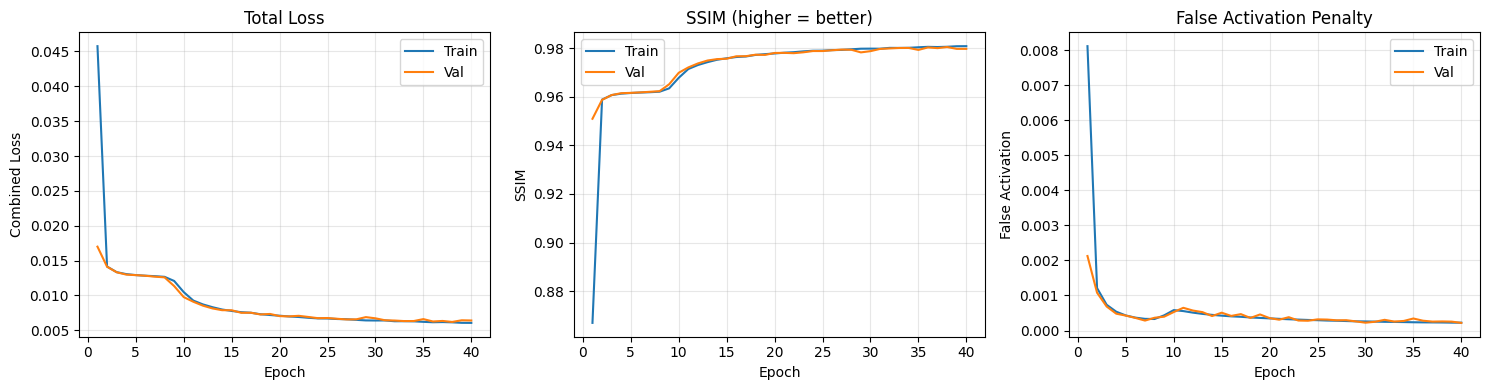

In [22]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs_range = range(1, len(train_history) + 1)
t = [h['loss'] for h in train_history]
v = [h['loss'] for h in val_history]

axes[0].plot(epochs_range, t, label='Train')
axes[0].plot(epochs_range, v, label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Combined Loss')
axes[0].set_title('Total Loss'); axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, [h['ssim'] for h in train_history], label='Train')
axes[1].plot(epochs_range, [h['ssim'] for h in val_history], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('SSIM')
axes[1].set_title('SSIM (higher = better)'); axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, [h['false_act'] for h in train_history], label='Train')
axes[2].plot(epochs_range, [h['false_act'] for h in val_history], label='Val')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('False Activation')
axes[2].set_title('False Activation Penalty'); axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluation Metrics

Compute on the validation set:
- Mean Squared Error
- Structural Similarity Index (SSIM) via scikit-image
- Sparsity metric: % of pixels predicted > 0.01 in truly empty regions

In [23]:
# Load best model
model.load_state_dict(torch.load('/content/Genie-Task/common_task1_autoencoder/models/conv_autoencoder.pth', map_location=device))
model.eval()

mse_scores = []
ssim_scores = []
false_positive_rates = []

with torch.no_grad():
    for imgs, masks, _ in val_loader:
        imgs_dev = imgs.to(device)
        recons = model(imgs_dev).cpu().numpy()
        imgs_np = imgs.numpy()

        for i in range(len(imgs_np)):
            orig = imgs_np[i]
            recon = recons[i]

            # MSE
            mse_scores.append(np.mean((orig - recon) ** 2))

            # SSIM (expects H, W, C)
            orig_hwc = orig.transpose(1, 2, 0)
            recon_hwc = np.clip(recon.transpose(1, 2, 0), 0, 1)
            ssim_val = compare_ssim(orig_hwc, recon_hwc, channel_axis=2, data_range=1.0)
            ssim_scores.append(ssim_val)

            # Sparsity: % of pixels predicted > 0.01 where original is empty
            empty_mask = orig < 0.01
            if empty_mask.sum() > 0:
                false_positives = (recon[empty_mask] > 0.01).mean() * 100
                false_positive_rates.append(false_positives)

print("=" * 50)
print("EVALUATION METRICS (Validation Set)")
print("=" * 50)
print(f"Mean MSE:                {np.mean(mse_scores):.6f}")
print(f"Mean SSIM:               {np.mean(ssim_scores):.4f}")
print(f"False Activation Rate:   {np.mean(false_positive_rates):.2f}%")
print(f"  (% of empty pixels predicted > 0.01)")
print("=" * 50)

EVALUATION METRICS (Validation Set)
Mean MSE:                0.000197
Mean SSIM:               0.9804
False Activation Rate:   0.33%
  (% of empty pixels predicted > 0.01)


## 7. Visualizations

Side-by-side comparison of Original vs Reconstructed for each detector channel (ECAL, HCAL, Tracks) across 5 random events.

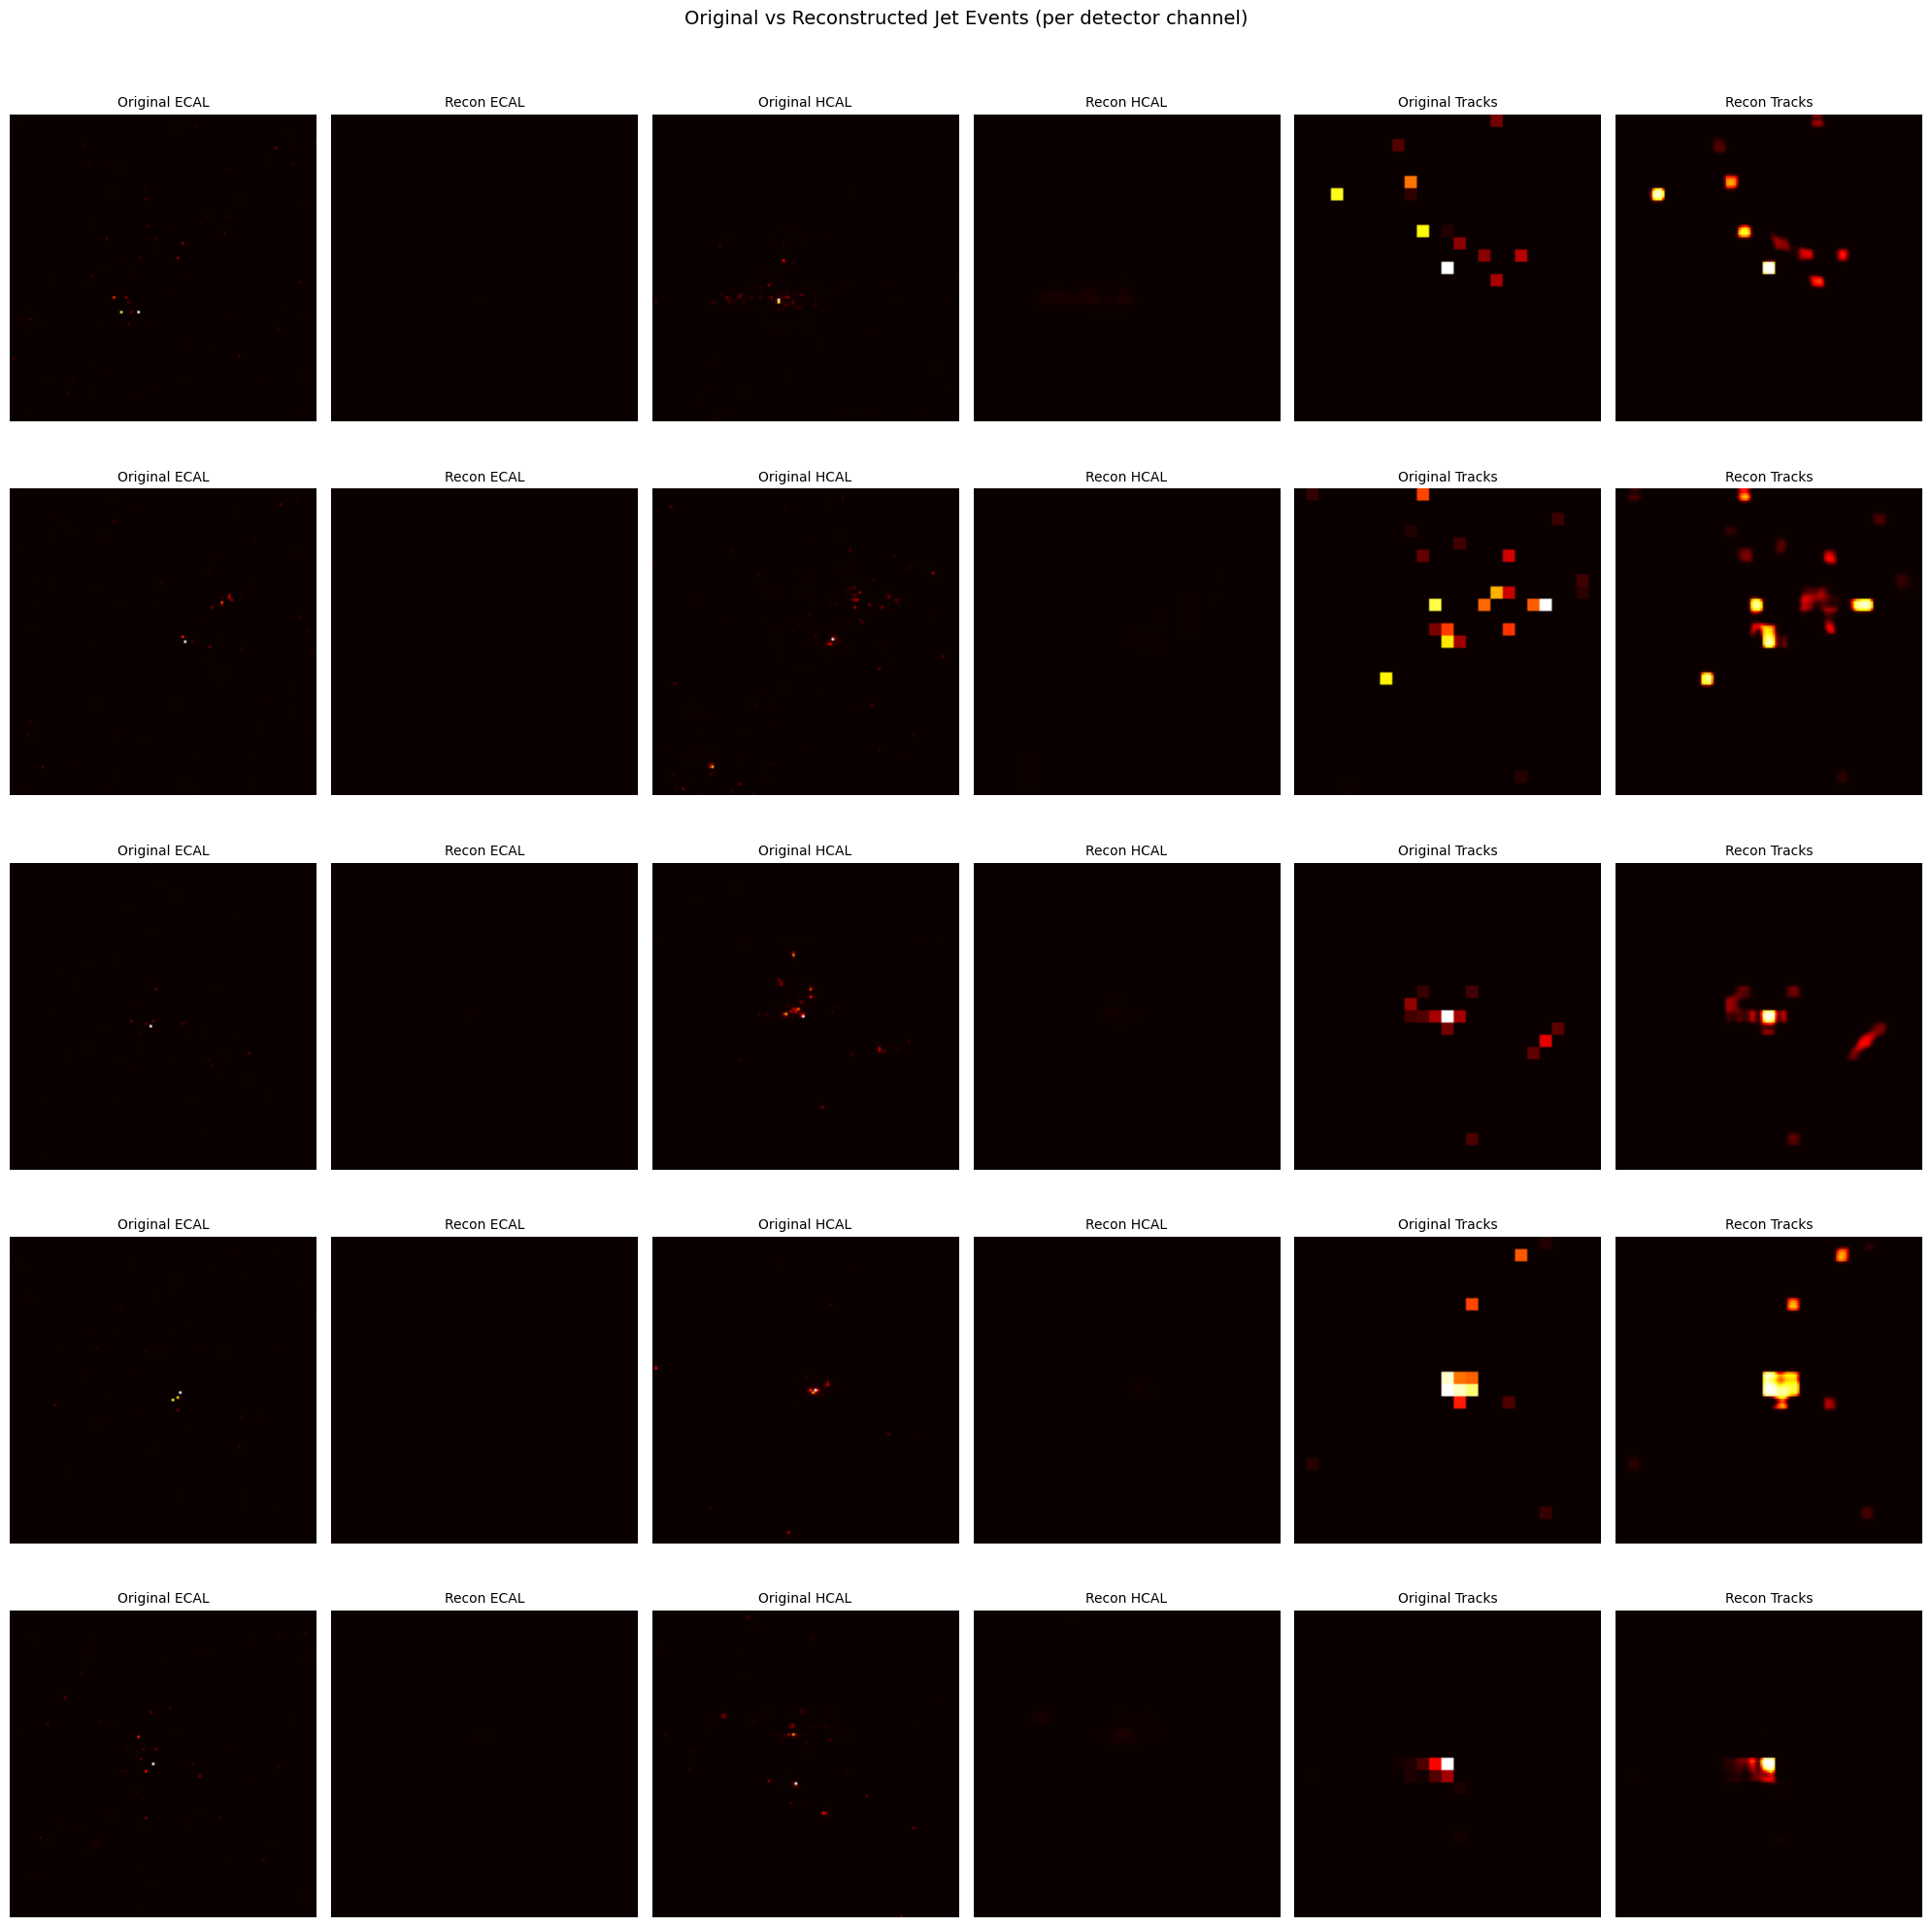

Saved comparison.png


In [24]:
def visualize_reconstructions(model, loader, device, n_events=5, seed=42):
    """Plot Original vs Reconstructed for each channel across n random events."""
    model.eval()
    channel_names = ['ECAL', 'HCAL', 'Tracks']

    # Collect all validation images
    all_imgs, all_recons = [], []
    with torch.no_grad():
        for imgs, _, _ in loader:
            imgs_dev = imgs.to(device)
            recons = model(imgs_dev).cpu()
            all_imgs.append(imgs)
            all_recons.append(recons)

    all_imgs = torch.cat(all_imgs, dim=0)
    all_recons = torch.cat(all_recons, dim=0)

    # Select random events
    rng = np.random.RandomState(seed)
    indices = rng.choice(len(all_imgs), size=n_events, replace=False)

    fig, axes = plt.subplots(n_events, 6, figsize=(20, 4 * n_events))
    if n_events == 1:
        axes = axes[np.newaxis, :]

    for row, idx in enumerate(indices):
        orig = all_imgs[idx].numpy()
        recon = all_recons[idx].numpy()

        for ch in range(3):
            vmin = 0
            vmax = max(orig[ch].max(), recon[ch].max())
            if vmax < 1e-6:
                vmax = 1.0

            # Original
            ax_orig = axes[row, ch * 2]
            ax_orig.imshow(orig[ch], cmap='hot', vmin=vmin, vmax=vmax)
            ax_orig.set_title(f'Original {channel_names[ch]}', fontsize=10)
            ax_orig.axis('off')

            # Reconstructed
            ax_recon = axes[row, ch * 2 + 1]
            ax_recon.imshow(recon[ch], cmap='hot', vmin=vmin, vmax=vmax)
            ax_recon.set_title(f'Recon {channel_names[ch]}', fontsize=10)
            ax_recon.axis('off')

        axes[row, 0].set_ylabel(f'Event {idx}', fontsize=10, rotation=0, labelpad=50)

    plt.suptitle('Original vs Reconstructed Jet Events (per detector channel)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved comparison.png")

visualize_reconstructions(model, val_loader, device, n_events=5)

In [25]:
print(f"Best model saved to: models/conv_autoencoder.pth")
print(f"Final Val MSE:  {np.mean(mse_scores):.6f}")
print(f"Final Val SSIM: {np.mean(ssim_scores):.4f}")
print(f"False Act Rate: {np.mean(false_positive_rates):.2f}%")

Best model saved to: models/conv_autoencoder.pth
Final Val MSE:  0.000197
Final Val SSIM: 0.9804
False Act Rate: 0.33%


In [16]:
print("TRAINING SUMMARY")
print(f"Epochs: {len(train_history)}")
print(f"Best val loss: {best_val_loss:.6f}")
print(f"Final train SSIM: {train_history[-1]['ssim']:.4f}")
print(f"Final val SSIM: {val_history[-1]['ssim']:.4f}")
print(f"Final FA: {val_history[-1]['false_act']:.6f}")

TRAINING SUMMARY
Epochs: 1
Best val loss: 0.212601
Final train SSIM: 0.1226
Final val SSIM: 0.4356
Final FA: 0.065921
